# Ensemble Learning — Concepts, Math, and Code

A from-first-principles tour of ensemble methods: **why** combining models works, the **math**
behind each technique, and **runnable code** that makes every idea concrete.

**Roadmap**

1. [Why Ensembles Work](#part1) — wisdom of crowds, bias–variance decomposition
2. [Bagging Family](#part2) — Bagging, Random Forest, Extra Trees
3. [Boosting Family](#part3) — AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost
4. [Combining Trained Models](#part4) — Voting, Stacking, Blending
5. [Practical Guide](#part5) — tuning, early stopping, benchmark, decision guide

> Every section follows the same pattern: **intuition → math derivation → code demo you can
> rerun and modify**. Feel free to tweak parameters in the code cells and re-run to build
> intuition interactively.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import time
import warnings
warnings.filterwarnings("ignore")

RNG = np.random.RandomState(42)
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
COLORS = dict(blue="#3B6FA0", green="#4C8C6B", amber="#C97A33", rose="#B3536B",
              gold="#B8923A", teal="#2F8F82", violet="#6E63A6", dim="#8A8F98")

# ---- Shared datasets used throughout the notebook ----

# 1D regression: a noisy "hump" function — used for bagging/boosting residual demos
def true_function(x):
    return 3 * np.sin(1.6 * x) + 0.4 * x

x_reg = np.sort(RNG.uniform(-4, 4, 220))
y_reg = true_function(x_reg) + RNG.normal(0, 0.7, size=x_reg.shape)
X_reg = x_reg.reshape(-1, 1)

x_grid = np.linspace(-4.3, 4.3, 400)
X_grid = x_grid.reshape(-1, 1)

# 2D classification: two interleaving moons-like clusters — used for decision-boundary demos
from sklearn.datasets import make_moons, make_classification
X_clf, y_clf = make_moons(n_samples=300, noise=0.28, random_state=42)

# Higher-dimensional tabular classification — used for RF/boosting/stacking benchmarks
X_tab, y_tab = make_classification(
    n_samples=2000, n_features=20, n_informative=8, n_redundant=4,
    n_clusters_per_class=2, flip_y=0.03, class_sep=1.0, random_state=42
)
from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(X_tab, y_tab, test_size=0.25, random_state=42)

print("Regression demo set:", X_reg.shape, "  Moons classification:", X_clf.shape,
      "  Tabular classification:", X_tab.shape)

Regression demo set: (220, 1)   Moons classification: (300, 2)   Tabular classification: (2000, 20)


<a id="part1"></a>
## Part 1 — Why Ensembles Work

### 1.1 The Wisdom of Crowds

Suppose $n$ independent models each estimate a quantity $y$ with random error:

$$\hat y_i = y + \varepsilon_i, \qquad \mathbb{E}[\varepsilon_i] = 0, \quad \text{Var}(\varepsilon_i) = \sigma^2$$

Average their predictions. Using $\text{Var}(cX) = c^2\text{Var}(X)$ and additivity of variance
for **independent** variables:

$$
\text{Var}\!\left(\frac{1}{n}\sum_{i=1}^n \hat y_i\right)
= \frac{1}{n^2}\sum_{i=1}^n \text{Var}(\hat y_i)
= \frac{n\sigma^2}{n^2} = \frac{\sigma^2}{n}
$$

The average is **still unbiased** ($\mathbb{E}=y$), but its variance shrinks by a factor of $n$.
This is the entire mathematical seed that every method in this notebook grows from — bagging,
boosting, and stacking are all, in one way or another, engineered ways to keep sub-model errors
as uncorrelated as possible so this $1/n$ shrinkage actually pays off.

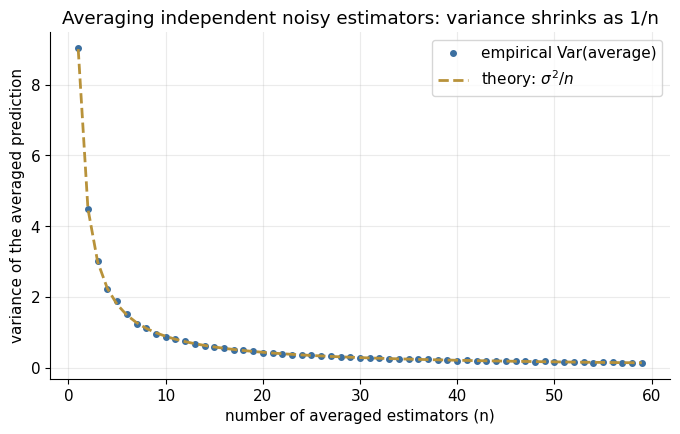

At n=1: variance ≈ 9.03 (≈ σ² = 9.00)
At n=59: variance ≈ 0.148 (≈ σ²/n = 0.153)


In [2]:
# Demo: simulate many "independent noisy estimators" of a single true value,
# and watch Var(average) shrink as 1/n — exactly as the formula predicts.
true_value = 10.0
sigma = 3.0
n_estimators_list = np.arange(1, 60)
n_trials = 4000

avg_variances = []
for n in n_estimators_list:
    # n_trials independent experiments, each averaging n noisy estimators
    samples = true_value + RNG.normal(0, sigma, size=(n_trials, n))
    trial_averages = samples.mean(axis=1)
    avg_variances.append(trial_averages.var())

fig, ax = plt.subplots()
ax.plot(n_estimators_list, avg_variances, "o", color=COLORS["blue"], ms=4, label="empirical Var(average)")
ax.plot(n_estimators_list, sigma**2 / n_estimators_list, "--", color=COLORS["gold"], lw=2, label=r"theory: $\sigma^2/n$")
ax.set_xlabel("number of averaged estimators (n)")
ax.set_ylabel("variance of the averaged prediction")
ax.set_title("Averaging independent noisy estimators: variance shrinks as 1/n")
ax.legend()
plt.show()
print(f"At n=1: variance ≈ {avg_variances[0]:.2f} (≈ σ² = {sigma**2:.2f})")
print(f"At n={n_estimators_list[-1]}: variance ≈ {avg_variances[-1]:.3f} "
      f"(≈ σ²/n = {sigma**2/n_estimators_list[-1]:.3f})")

### 1.2 The Bias–Variance Decomposition

For squared error, a model's expected error at a point decomposes exactly into three additive
pieces. Let $\bar f(x) = \mathbb{E}_{\mathcal D}[\hat f(x)]$ be the prediction averaged over all
possible training sets $\mathcal D$, and let $y = \bar y + \varepsilon$ where $\varepsilon$ is
irreducible noise. Add and subtract $\bar f(x)$ inside the square and expand:

$$
\mathbb{E}[(y-\hat f)^2] = \mathbb{E}\big[((y-\bar f) + (\bar f-\hat f))^2\big]
= \underbrace{\mathbb{E}[(y-\bar f)^2]}_{\text{Bias}^2 + \sigma^2} \;+\; \underbrace{\mathbb{E}[(\bar f-\hat f)^2]}_{\text{Variance}} \;+\; 2\,\mathbb{E}[(y-\bar f)(\bar f-\hat f)]
$$

The cross term vanishes (the noise in a fresh test point $y$ is independent of $\hat f$, so it
averages to 0), leaving:

$$\mathbb{E}[(y-\hat f(x))^2] = \underbrace{(\text{Bias}[\hat f(x)])^2}_{\text{systematic error}} + \underbrace{\text{Var}[\hat f(x)]}_{\text{sensitivity to training data}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

* **Bias** — how far off the model's *average* prediction is from the truth, across many retrainings.
* **Variance** — how much predictions *wobble* across those retrainings.
* Deep, unpruned trees: low bias, high variance → **bagging** averages the variance away.
* Shallow trees / stumps: high bias, low variance → **boosting** chains them to remove the bias.

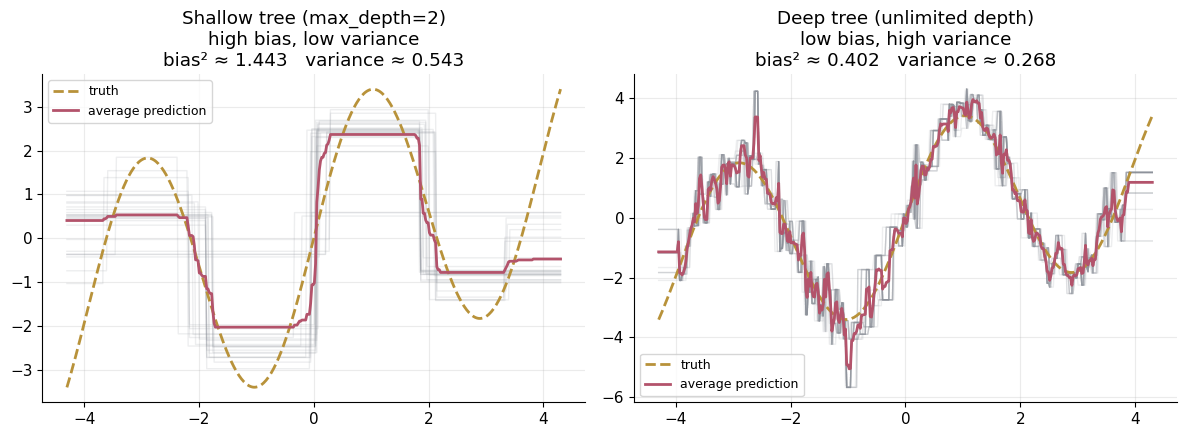

Model          Bias²    Variance     Bias²+Var
Shallow        1.443       0.543         1.986
Deep           0.402       0.268         0.671


In [3]:
# Demo: empirically measure bias^2 and variance of shallow vs. deep trees,
# by retraining on many bootstrap resamples of the same underlying function.
from sklearn.tree import DecisionTreeRegressor

def bias_variance(model_fn, n_repeats=120):
    preds = np.zeros((n_repeats, len(x_grid)))
    for i in range(n_repeats):
        idx = RNG.choice(len(X_reg), len(X_reg), replace=True)   # a fresh "training set"
        model = model_fn()
        model.fit(X_reg[idx], y_reg[idx])
        preds[i] = model.predict(X_grid)
    mean_pred = preds.mean(axis=0)
    bias2 = (mean_pred - true_function(x_grid)) ** 2
    variance = preds.var(axis=0)
    return preds, mean_pred, bias2.mean(), variance.mean()

shallow_preds, shallow_mean, shallow_bias2, shallow_var = bias_variance(lambda: DecisionTreeRegressor(max_depth=2))
deep_preds, deep_mean, deep_bias2, deep_var = bias_variance(lambda: DecisionTreeRegressor(max_depth=None))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, preds, mean_pred, title, b2, v in [
    (axes[0], shallow_preds, shallow_mean, "Shallow tree (max_depth=2)\nhigh bias, low variance", shallow_bias2, shallow_var),
    (axes[1], deep_preds, deep_mean, "Deep tree (unlimited depth)\nlow bias, high variance", deep_bias2, deep_var),
]:
    for p in preds[:25]:
        ax.plot(x_grid, p, color=COLORS["dim"], alpha=0.15, lw=1)
    ax.plot(x_grid, true_function(x_grid), "--", color=COLORS["gold"], lw=2, label="truth")
    ax.plot(x_grid, mean_pred, color=COLORS["rose"], lw=2, label="average prediction")
    ax.set_title(f"{title}\nbias² ≈ {b2:.3f}   variance ≈ {v:.3f}")
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'Model':<10}{'Bias²':>10}{'Variance':>12}{'Bias²+Var':>14}")
print(f"{'Shallow':<10}{shallow_bias2:>10.3f}{shallow_var:>12.3f}{shallow_bias2+shallow_var:>14.3f}")
print(f"{'Deep':<10}{deep_bias2:>10.3f}{deep_var:>12.3f}{deep_bias2+deep_var:>14.3f}")

### 1.3 Two Families

| | **Bagging** | **Boosting** |
|---|---|---|
| Training | Parallel, independent | Sequential, adaptive |
| Targets | **Variance** | **Bias** |
| Base learner | Low-bias, high-variance (deep trees) | High-bias, low-variance (shallow trees/stumps) |
| Overfits with more models? | Rarely | Can, needs early stopping |

Both are special cases of one expression, $\hat y(x) = \sum_k \beta_k h_k(x)$ — they only differ
in *how* $h_k$ and $\beta_k$ are chosen. We'll return to this unifying view at the very end.

<a id="part2"></a>
## Part 2 — Bagging Family

### 2.1 Bootstrap Sampling & the 36.8% Rule

A bootstrap sample of size $n$ draws $n$ points **with replacement** from the original $n$-point
dataset. The probability a specific point is *never* drawn in one sample is:

$$P(\text{excluded}) = \left(\frac{n-1}{n}\right)^n \xrightarrow[n\to\infty]{} e^{-1} \approx 0.368$$

So each bootstrap sample contains roughly **63.2%** of the unique points (some duplicated) and
leaves about **36.8%** out — the **out-of-bag (OOB)** points, which give every tree a free,
built-in validation set with no separate holdout split required.

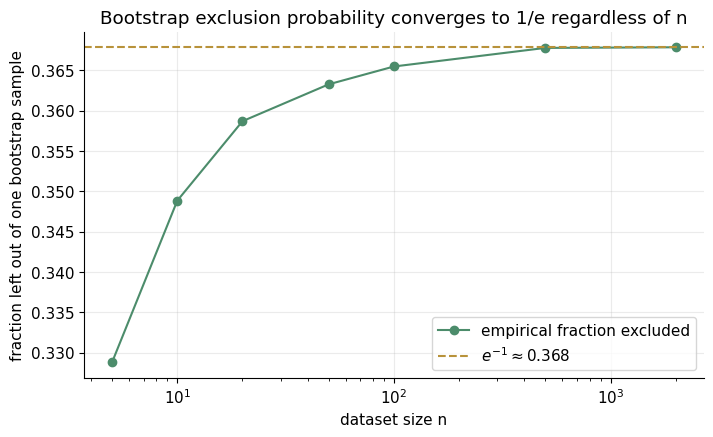

n=5      excluded ≈ 0.329   theory (n-1)/n)^n = 0.328
n=10     excluded ≈ 0.349   theory (n-1)/n)^n = 0.349
n=20     excluded ≈ 0.359   theory (n-1)/n)^n = 0.358
n=50     excluded ≈ 0.363   theory (n-1)/n)^n = 0.364
n=100    excluded ≈ 0.365   theory (n-1)/n)^n = 0.366
n=500    excluded ≈ 0.368   theory (n-1)/n)^n = 0.368
n=2000   excluded ≈ 0.368   theory (n-1)/n)^n = 0.368


In [4]:
# Verify the 36.8% rule empirically, and see how fast it converges as n grows.
def fraction_excluded(n, n_trials=3000):
    counts = np.zeros(n_trials)
    for t in range(n_trials):
        sample_idx = RNG.randint(0, n, size=n)
        counts[t] = 1 - len(np.unique(sample_idx)) / n
    return counts.mean()

ns = [5, 10, 20, 50, 100, 500, 2000]
fracs = [fraction_excluded(n) for n in ns]

fig, ax = plt.subplots()
ax.plot(ns, fracs, "o-", color=COLORS["green"], label="empirical fraction excluded")
ax.axhline(1/np.e, ls="--", color=COLORS["gold"], label=r"$e^{-1} \approx 0.368$")
ax.set_xscale("log")
ax.set_xlabel("dataset size n"); ax.set_ylabel("fraction left out of one bootstrap sample")
ax.set_title("Bootstrap exclusion probability converges to 1/e regardless of n")
ax.legend(); plt.show()
for n, f in zip(ns, fracs):
    print(f"n={n:<6d} excluded ≈ {f:.3f}   theory (n-1)/n)^n = {((n-1)/n)**n:.3f}")

### 2.2 Aggregation & the Correlation Floor

Averaging $B$ trees with per-tree variance $\sigma^2$ and pairwise correlation $\rho$: expand
$\text{Var}\!\left(\frac1B\sum_b \hat f_b\right)$ using $\text{Cov}(X_i,X_j)=\rho\sigma^2$ for $i\ne j$:

$$
\text{Var}\!\left(\frac{1}{B}\sum_{b=1}^B \hat f_b\right)
= \frac{1}{B^2}\Big[\underbrace{B\sigma^2}_{B\text{ variance terms}} + \underbrace{B(B{-}1)\rho\sigma^2}_{B(B-1)\text{ covariance terms}}\Big]
= \frac{\sigma^2}{B} + \frac{B-1}{B}\rho\sigma^2 \xrightarrow[B\to\infty]{} \rho\sigma^2
$$

As $B\to\infty$ the first term vanishes, but $\rho\sigma^2$ is a **floor** more trees can never
average away. This is the entire justification for Random Forest's extra trick, next section.

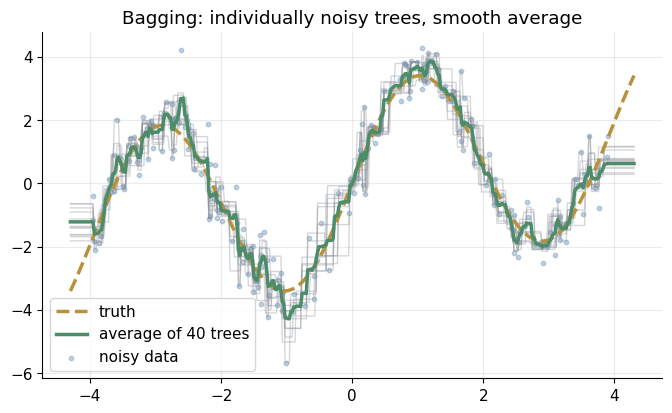

Average per-tree variance across the grid: 0.2045


In [5]:
# Demo: bag several regression trees on the 1D function and watch the average
# get smoother (lower variance) than any individual tree.
B = 40
bagged_preds = np.zeros((B, len(x_grid)))
for b in range(B):
    idx = RNG.choice(len(X_reg), len(X_reg), replace=True)
    tree = DecisionTreeRegressor(max_depth=None, min_samples_leaf=3, random_state=b)
    tree.fit(X_reg[idx], y_reg[idx])
    bagged_preds[b] = tree.predict(X_grid)

fig, ax = plt.subplots()
for p in bagged_preds[:12]:
    ax.plot(x_grid, p, color=COLORS["dim"], alpha=0.35, lw=1)
ax.plot(x_grid, true_function(x_grid), "--", color=COLORS["gold"], lw=2.5, label="truth")
ax.plot(x_grid, bagged_preds.mean(axis=0), color=COLORS["green"], lw=2.5, label=f"average of {B} trees")
ax.scatter(x_reg, y_reg, s=10, color=COLORS["blue"], alpha=0.3, label="noisy data")
ax.set_title("Bagging: individually noisy trees, smooth average")
ax.legend(); plt.show()

single_tree_var = bagged_preds.var(axis=0).mean()
avg_var = np.var([bagged_preds[:k].mean(axis=0) for k in range(1, B+1)], axis=1)
print(f"Average per-tree variance across the grid: {bagged_preds.var(axis=0).mean():.4f}")

### 2.3 Random Forest — Decorrelating the Trees

Random Forest = bagging **+** one extra trick: at *every split*, only let the tree choose from a
random subset of $m$ features (typically $m=\sqrt p$ for classification, $m=p/3$ for regression).
When the single dominant feature isn't even available at a given split, trees are forced down
different paths — directly shrinking $\rho$, and therefore the $\rho\sigma^2$ floor above.

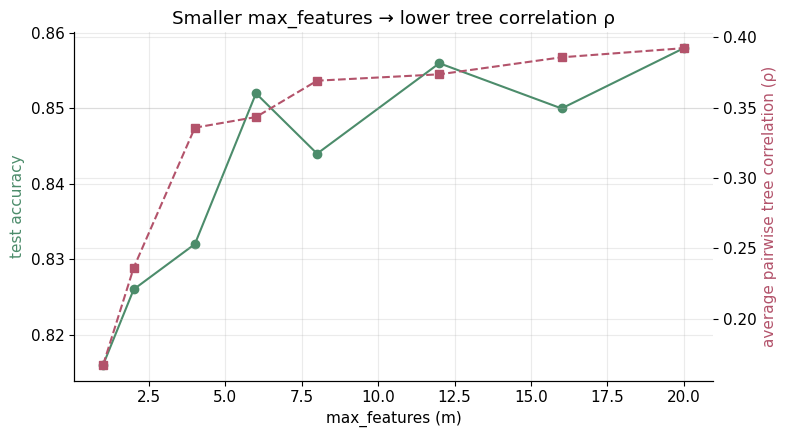

In [6]:
# Demo: as max_features shrinks, tree-to-tree correlation drops and (up to a point)
# ensemble accuracy on held-out data improves.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

max_features_grid = [1, 2, 4, 6, 8, 12, 16, 20]
accuracies, correlations = [], []

for mf in max_features_grid:
    rf = RandomForestClassifier(n_estimators=60, max_features=mf, random_state=0, n_jobs=-1)
    rf.fit(Xtr, ytr)
    accuracies.append(accuracy_score(yte, rf.predict(Xte)))

    # estimate average pairwise correlation between trees' predicted probabilities on test set
    tree_probs = np.array([t.predict_proba(Xte)[:, 1] for t in rf.estimators_])
    corr = np.corrcoef(tree_probs)
    off_diag = corr[np.triu_indices_from(corr, k=1)]
    correlations.append(off_diag.mean())

fig, ax1 = plt.subplots()
ax1.plot(max_features_grid, accuracies, "o-", color=COLORS["green"], label="test accuracy")
ax1.set_xlabel("max_features (m)"); ax1.set_ylabel("test accuracy", color=COLORS["green"])
ax2 = ax1.twinx()
ax2.plot(max_features_grid, correlations, "s--", color=COLORS["rose"], label="avg. tree correlation ρ")
ax2.set_ylabel("average pairwise tree correlation (ρ)", color=COLORS["rose"])
ax1.set_title("Smaller max_features → lower tree correlation ρ")
fig.tight_layout(); plt.show()

### 2.4 Out-of-Bag Error & Feature Importance

$$\text{OOB error} = \frac1n\sum_{i=1}^n L\Big(y_i,\ \text{aggregate of } \{\hat f_b(x_i): x_i \notin \text{sample}_b\}\Big)$$

**Mean Decrease in Impurity** importance sums how much each feature reduces Gini impurity
$G=1-\sum_k p_k^2$ every time it's used for a split, averaged over all trees:

$$\text{Importance}(f) = \frac1B\sum_{b=1}^B \sum_{\text{splits on }f\text{ in tree }b} \Delta\text{impurity}$$

It's fast but biased toward high-cardinality features — **permutation importance** (shuffle one
column, remeasure error) is slower but far less biased.

OOB accuracy estimate: 0.843   |   actual test accuracy: 0.846


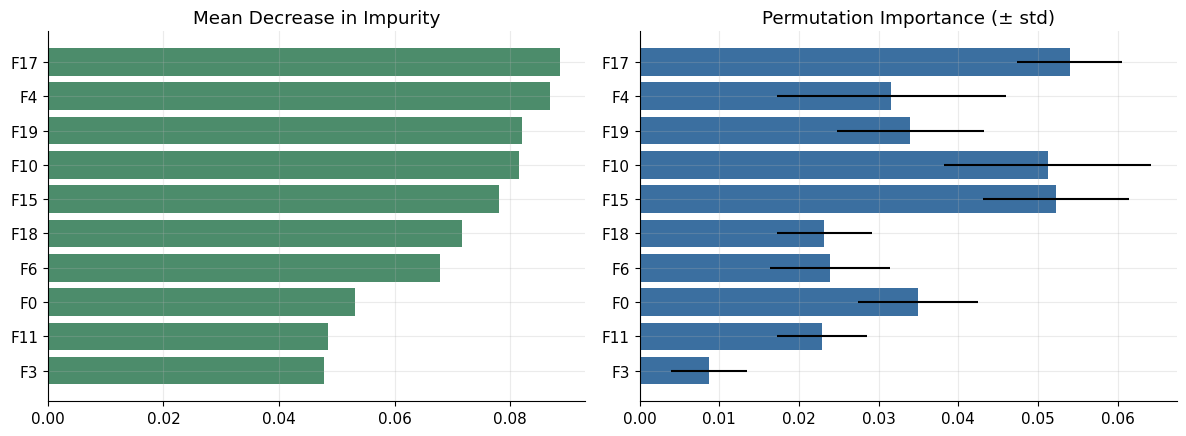

In [7]:
from sklearn.inspection import permutation_importance

rf = RandomForestClassifier(n_estimators=200, max_features="sqrt", oob_score=True, random_state=0, n_jobs=-1)
rf.fit(Xtr, ytr)
print(f"OOB accuracy estimate: {rf.oob_score_:.3f}   |   actual test accuracy: {accuracy_score(yte, rf.predict(Xte)):.3f}")

perm = permutation_importance(rf, Xte, yte, n_repeats=15, random_state=0, n_jobs=-1)
order = np.argsort(rf.feature_importances_)[::-1][:10]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(range(10), rf.feature_importances_[order][::-1], color=COLORS["green"])
axes[0].set_yticks(range(10)); axes[0].set_yticklabels([f"F{i}" for i in order][::-1])
axes[0].set_title("Mean Decrease in Impurity")

axes[1].barh(range(10), perm.importances_mean[order][::-1], xerr=perm.importances_std[order][::-1], color=COLORS["blue"])
axes[1].set_yticks(range(10)); axes[1].set_yticklabels([f"F{i}" for i in order][::-1])
axes[1].set_title("Permutation Importance (± std)")
plt.tight_layout(); plt.show()

### 2.5 Extra Trees — Extremely Randomized

Random Forest still **searches** for the optimal threshold on each candidate feature. Extra
Trees skips the search: it draws a threshold **uniformly at random** and keeps the best of those
random cuts. Higher per-tree bias, but lower correlation between trees (and much faster to train)
— another point on the same $\rho\sigma^2$ trade-off curve.

In [8]:
from sklearn.ensemble import ExtraTreesClassifier

results = {}
for name, Model in [("Random Forest", RandomForestClassifier), ("Extra Trees", ExtraTreesClassifier)]:
    t0 = time.time()
    model = Model(n_estimators=200, random_state=0, n_jobs=-1).fit(Xtr, ytr)
    fit_time = time.time() - t0
    acc = accuracy_score(yte, model.predict(Xte))
    results[name] = (acc, fit_time)
    print(f"{name:<16} accuracy={acc:.3f}   fit_time={fit_time:.3f}s")

Random Forest    accuracy=0.846   fit_time=0.951s


Extra Trees      accuracy=0.858   fit_time=0.539s


<a id="part3"></a>
## Part 3 — Boosting Family

### 3.1 AdaBoost — Focus on What You Got Wrong

Train weak learners sequentially. After round $t$, compute the **weighted error**:

$$\varepsilon_t = \sum_{i:\,h_t(x_i)\neq y_i} w_i$$

Give that learner a voice $\alpha_t$ — derived by minimizing exponential loss, coordinate-descent
style:

$$\alpha_t = \frac12\ln\!\left(\frac{1-\varepsilon_t}{\varepsilon_t}\right)$$

$\varepsilon_t=0.5$ (coin flip) → $\alpha_t=0$ (ignored). $\varepsilon_t\to 0$ → $\alpha_t\to\infty$
(fully trusted). Then reweight every point — misclassified points get heavier:

$$w_i \leftarrow w_i \cdot e^{-\alpha_t y_i h_t(x_i)}, \quad \text{renormalize so } \textstyle\sum_i w_i=1$$

Final vote: $H(x) = \text{sign}\!\left(\sum_t \alpha_t h_t(x)\right)$. Schapire's 1990 theorem
guarantees the **training** error shrinks *exponentially*: $\text{error}_T \le e^{-2\gamma^2 T}$
whenever every weak learner has edge $\gamma$ over random guessing — however tiny $\gamma$ is,
enough rounds drive error to zero.

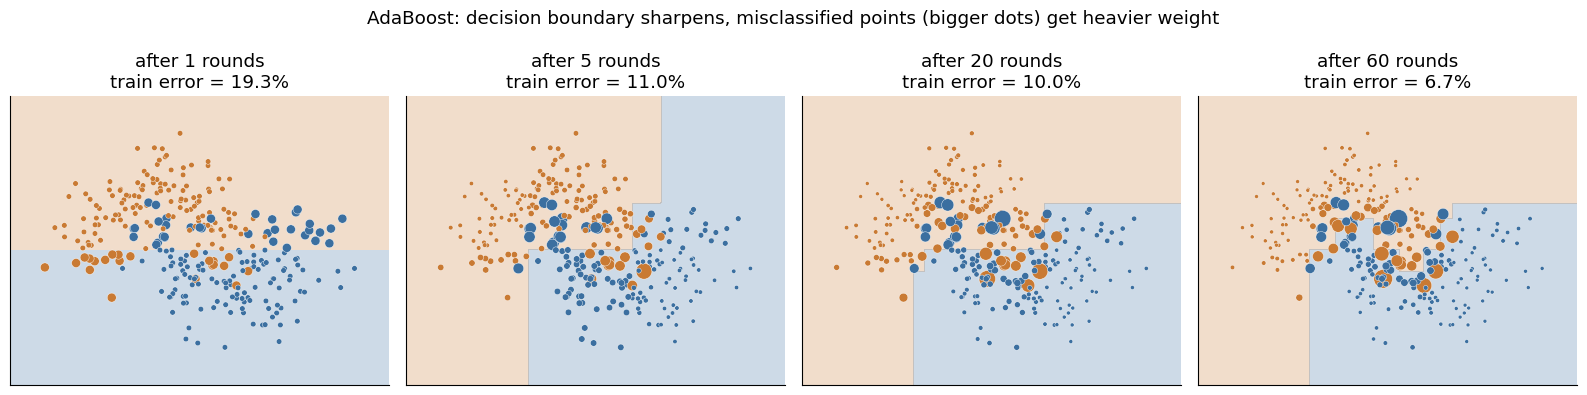

In [9]:
# From-scratch AdaBoost (the classic SAMME / exponential-loss derivation), implemented
# with decision stumps (max_depth=1) as weak learners, on the 2D "moons" dataset.
from sklearn.tree import DecisionTreeClassifier

y_pm = np.where(y_clf == 1, 1, -1)  # {0,1} -> {-1,+1} to match the math above

def adaboost_fit(X, y_pm, n_rounds=60):
    n = len(y_pm)
    w = np.full(n, 1 / n)
    stumps, alphas, epsilons, weight_history = [], [], [], [w.copy()]
    for t in range(n_rounds):
        stump = DecisionTreeClassifier(max_depth=1, random_state=t)
        stump.fit(X, y_pm, sample_weight=w)
        pred = stump.predict(X)
        miss = (pred != y_pm).astype(float)
        eps = np.clip(np.sum(w * miss), 1e-10, 1 - 1e-10)
        alpha = 0.5 * np.log((1 - eps) / eps)
        w = w * np.exp(-alpha * y_pm * pred)
        w = w / w.sum()
        stumps.append(stump); alphas.append(alpha); epsilons.append(eps)
        weight_history.append(w.copy())
    return stumps, np.array(alphas), np.array(epsilons), weight_history

def adaboost_predict(stumps, alphas, X, n_rounds=None):
    n_rounds = n_rounds or len(stumps)
    agg = sum(alphas[t] * stumps[t].predict(X) for t in range(n_rounds))
    return np.sign(agg)

stumps, alphas, epsilons, weight_history = adaboost_fit(X_clf, y_pm, n_rounds=60)

# --- plot: decision boundary evolving, and point weights growing for hard cases ---
xx, yy = np.meshgrid(np.linspace(X_clf[:,0].min()-.5, X_clf[:,0].max()+.5, 250),
                      np.linspace(X_clf[:,1].min()-.5, X_clf[:,1].max()+.5, 250))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, rounds in zip(axes, [1, 5, 20, 60]):
    Z = adaboost_predict(stumps, alphas, grid, n_rounds=rounds).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-2,0,2], colors=[COLORS["amber"], COLORS["blue"]], alpha=0.25)
    sizes = weight_history[rounds][:] * 4000 + 8
    ax.scatter(X_clf[:,0], X_clf[:,1], c=np.where(y_pm==1, COLORS["blue"], COLORS["amber"]), s=sizes, edgecolor="white", linewidth=0.3)
    train_err = (adaboost_predict(stumps, alphas, X_clf, n_rounds=rounds) != y_pm).mean()
    ax.set_title(f"after {rounds} rounds\ntrain error = {train_err:.1%}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("AdaBoost: decision boundary sharpens, misclassified points (bigger dots) get heavier weight")
plt.tight_layout(); plt.show()

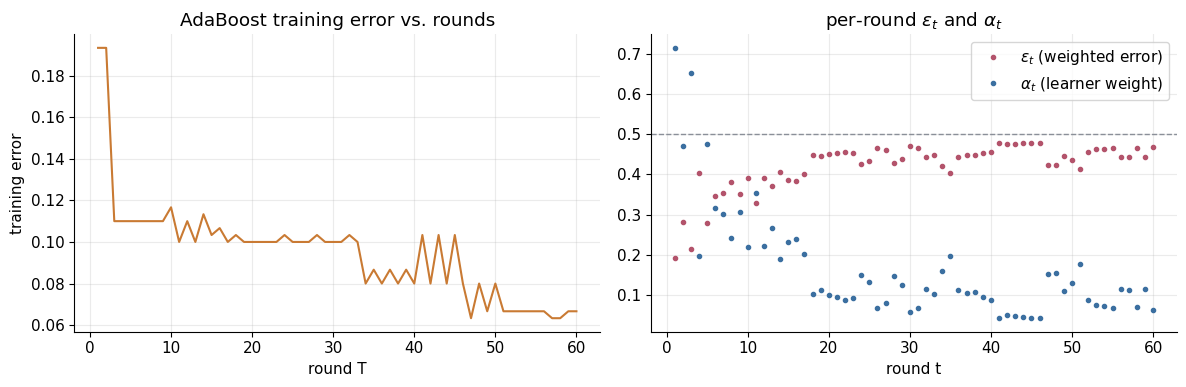

Round 1: ε₁=0.193  →  α₁ = ½ln((1-ε₁)/ε₁) = 0.714


In [10]:
# The theoretical exponential bound vs. what we actually observe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_errors = [(adaboost_predict(stumps, alphas, X_clf, n_rounds=t) != y_pm).mean() for t in range(1, 61)]
axes[0].plot(range(1, 61), train_errors, color=COLORS["amber"])
axes[0].set_xlabel("round T"); axes[0].set_ylabel("training error"); axes[0].set_title("AdaBoost training error vs. rounds")

axes[1].plot(range(1, 61), epsilons, "o", ms=3, color=COLORS["rose"], label=r"$\varepsilon_t$ (weighted error)")
axes[1].plot(range(1, 61), alphas, "o", ms=3, color=COLORS["blue"], label=r"$\alpha_t$ (learner weight)")
axes[1].axhline(0.5, ls="--", color=COLORS["dim"], lw=1)
axes[1].set_xlabel("round t"); axes[1].legend(); axes[1].set_title(r"per-round $\varepsilon_t$ and $\alpha_t$")
plt.tight_layout(); plt.show()
print(f"Round 1: ε₁={epsilons[0]:.3f}  →  α₁ = ½ln((1-ε₁)/ε₁) = {alphas[0]:.3f}")

### 3.2 Gradient Boosting — Fitting the Leftovers

Gradient boosting is **gradient descent in function space**. Ordinary gradient descent updates a
parameter vector, $\theta \leftarrow \theta - \eta\nabla_\theta L$. Here the "parameter" is the
whole prediction function $F$, and a tree is fit to approximate the negative gradient of the loss:

$$F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x), \qquad h_m \text{ fit to } -\left.\frac{\partial L(y_i,F(x_i))}{\partial F(x_i)}\right|_{F=F_{m-1}}$$

For squared error $L=\tfrac12(y-F)^2$, the negative gradient is exactly the **residual**:
$-\partial L/\partial F = y - F$ — so "fit a tree to the residuals" *is* gradient descent, not a
heuristic. Other losses (log-loss for classification, etc.) just swap in their own gradient.

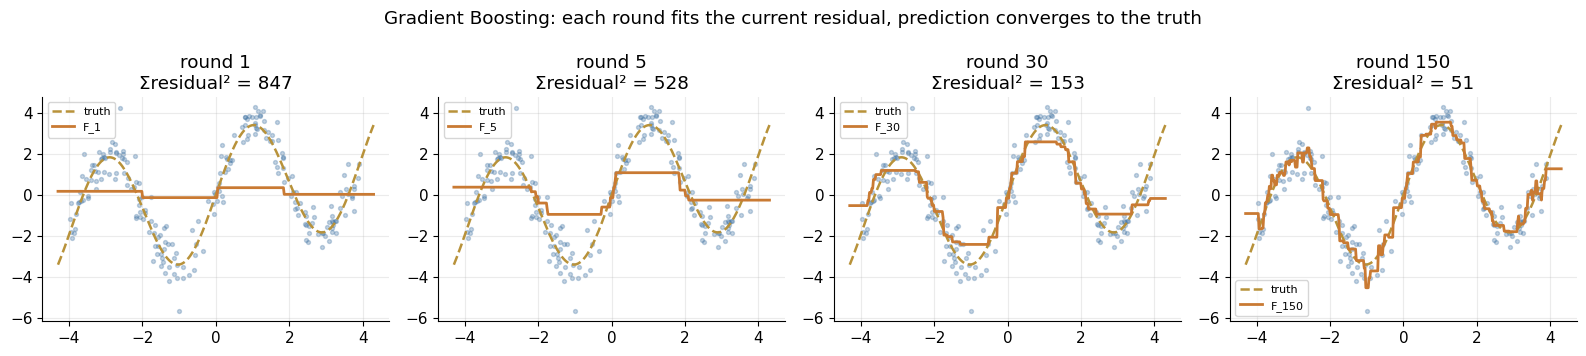

In [11]:
# From-scratch gradient boosting for regression: F_m = F_{m-1} + lr * tree(residuals)
def gb_fit(X, y, n_rounds=150, lr=0.1, max_depth=2):
    F0 = y.mean()
    F = np.full(len(y), F0)
    trees = []
    for _ in range(n_rounds):
        residual = y - F                                   # = negative gradient, for squared error
        tree = DecisionTreeRegressor(max_depth=max_depth)
        tree.fit(X, residual)
        F = F + lr * tree.predict(X)
        trees.append(tree)
    return F0, trees

def gb_predict(F0, trees, X, lr, n_rounds=None):
    n_rounds = n_rounds or len(trees)
    pred = np.full(len(X), F0)
    for t in range(n_rounds):
        pred = pred + lr * trees[t].predict(X)
    return pred

F0, trees = gb_fit(X_reg, y_reg, n_rounds=150, lr=0.1, max_depth=2)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
sse_curve = []
for ax, rounds in zip(axes, [1, 5, 30, 150]):
    pred = gb_predict(F0, trees, X_grid, lr=0.1, n_rounds=rounds)
    ax.scatter(x_reg, y_reg, s=8, color=COLORS["blue"], alpha=0.3)
    ax.plot(x_grid, true_function(x_grid), "--", color=COLORS["gold"], lw=1.8, label="truth")
    ax.plot(x_grid, pred, color=COLORS["amber"], lw=2, label=f"F_{rounds}")
    train_pred = gb_predict(F0, trees, X_reg, lr=0.1, n_rounds=rounds)
    sse = np.sum((y_reg - train_pred) ** 2)
    ax.set_title(f"round {rounds}\nΣresidual² = {sse:.0f}")
    ax.legend(fontsize=8)
plt.suptitle("Gradient Boosting: each round fits the current residual, prediction converges to the truth")
plt.tight_layout(); plt.show()

### 3.3 Learning Rate (Shrinkage)

$$F_m(x) = F_{m-1}(x) + \nu\cdot h_m(x), \qquad 0<\nu\le 1$$

Full commitment ($\nu=1$) bakes noise from any one residual permanently into the ensemble. Small
$\nu$ is a form of regularization: many honest small steps generalize better than a few large,
noise-sensitive ones — at the cost of needing more trees to get there.

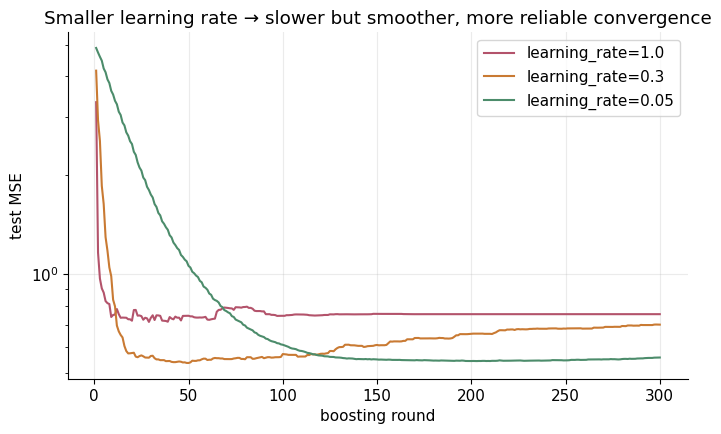

In [12]:
from sklearn.ensemble import GradientBoostingRegressor
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_reg, y_reg, test_size=0.3, random_state=0)

fig, ax = plt.subplots()
for lr, color in zip([1.0, 0.3, 0.05], [COLORS["rose"], COLORS["amber"], COLORS["green"]]):
    gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=lr, max_depth=2, random_state=0)
    gbr.fit(Xr_tr, yr_tr)
    test_mse = [np.mean((yr_te - pred) ** 2) for pred in gbr.staged_predict(Xr_te)]
    ax.plot(range(1, 301), test_mse, color=color, label=f"learning_rate={lr}")
ax.set_xlabel("boosting round"); ax.set_ylabel("test MSE"); ax.set_yscale("log")
ax.set_title("Smaller learning rate → slower but smoother, more reliable convergence")
ax.legend(); plt.show()

### 3.4 XGBoost — A Regularized, Curvature-Aware Objective

XGBoost approximates the loss with a **2nd-order Taylor expansion** (gradient *and* curvature),
plus an explicit complexity penalty:

$$L(y_i, F_{m-1}(x_i)+h(x_i)) \approx L(y_i,F_{m-1}(x_i)) + g_i h(x_i) + \tfrac12 u_i h(x_i)^2, \qquad \Omega(h)=\gamma T + \tfrac12\lambda\sum_j w_j^2$$

where $g_i=\partial L/\partial F$, $u_i=\partial^2 L/\partial F^2$. Minimizing over each leaf's
output $w_j$ (with $G_j=\sum g_i$, $H_j=\sum u_i$ summed over points in that leaf) gives a
**closed form**:

$$w_j^\* = -\frac{G_j}{H_j+\lambda}, \qquad \text{Gain} = \tfrac12\left[\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}-\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right]-\gamma$$

A split only happens if Gain is positive — the "is this split worth it" question is baked
directly into the objective, not bolted on afterward as a separate pruning heuristic.

With λ=1.0:  w* = -G/(H+λ) = -1.200
Without regularization: w* = -G/H = -1.500
Regularization pulled the leaf output 20% closer to zero.



Best iteration (early stopping): 128
Test accuracy: 0.826


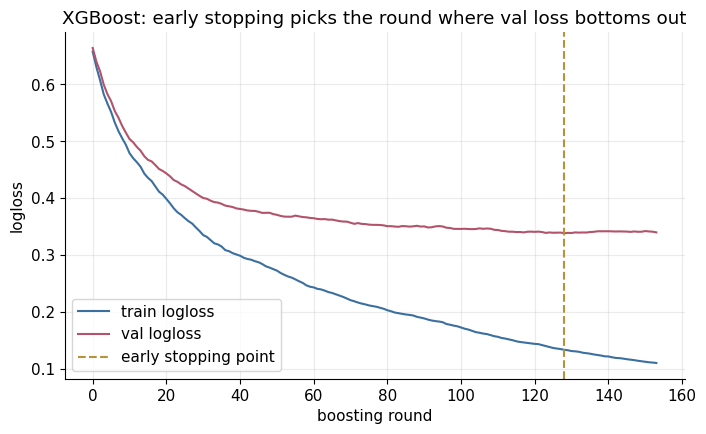

In [13]:
# Manual sanity check of the closed-form leaf weight, before touching the real library
G, H, lam = 6.0, 4.0, 1.0
w_reg = -G / (H + lam)
w_noreg = -G / H
print(f"With λ={lam}:  w* = -G/(H+λ) = {w_reg:.3f}")
print(f"Without regularization: w* = -G/H = {w_noreg:.3f}")
print(f"Regularization pulled the leaf output {100*(1 - w_reg/w_noreg):.0f}% closer to zero.\n")

import xgboost as xgb

Xt_tr, Xt_val, yt_tr, yt_val = train_test_split(Xtr, ytr, test_size=0.2, random_state=0)
dtrain = xgb.DMatrix(Xt_tr, label=yt_tr)
dval   = xgb.DMatrix(Xt_val, label=yt_val)
dtest  = xgb.DMatrix(Xte, label=yte)

params = dict(max_depth=4, eta=0.1, objective="binary:logistic", eval_metric="logloss",
              reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8)
evals_result = {}
bst = xgb.train(params, dtrain, num_boost_round=300,
                 evals=[(dtrain, "train"), (dval, "val")],
                 early_stopping_rounds=25, evals_result=evals_result, verbose_eval=False)

print(f"Best iteration (early stopping): {bst.best_iteration}")
pred = (bst.predict(dtest, iteration_range=(0, bst.best_iteration+1)) > 0.5).astype(int)
print(f"Test accuracy: {accuracy_score(yte, pred):.3f}")

fig, ax = plt.subplots()
ax.plot(evals_result["train"]["logloss"], color=COLORS["blue"], label="train logloss")
ax.plot(evals_result["val"]["logloss"], color=COLORS["rose"], label="val logloss")
ax.axvline(bst.best_iteration, ls="--", color=COLORS["gold"], label="early stopping point")
ax.set_xlabel("boosting round"); ax.set_ylabel("logloss")
ax.set_title("XGBoost: early stopping picks the round where val loss bottoms out")
ax.legend(); plt.show()

### 3.5 LightGBM — Grow Where It Hurts Most

Three independent speedups over level-wise growth:

1. **Leaf-wise growth**: always expand the single leaf with the largest loss reduction
   ($\arg\max_\ell \text{Gain}(\ell)$) instead of expanding every leaf at the current depth. Lower
   training loss for the same leaf budget, at the cost of trees that can grow deep and narrow
   (control with `max_depth` / `min_data_in_leaf`).
2. **Histogram binning**: bucket continuous features into ~255 bins up front, so split search
   becomes $O(\text{bins})$ instead of $O(n\log n)$ per feature.
3. **GOSS** (Gradient-based One-Side Sampling): keep all large-gradient ("still very wrong")
   points, randomly sample a fraction $b$ of the small-gradient ones, rescale their contribution
   by $\frac{1-a}{b}$ to keep the gradient sum unbiased.

XGBoost (hist)   fit_time= 2.52s   accuracy=0.977
LightGBM         fit_time= 2.93s   accuracy=0.977


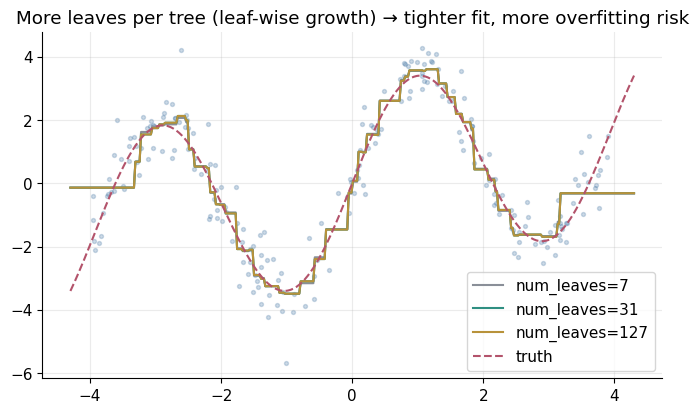

In [14]:
import lightgbm as lgb

# Larger dataset to make the speed difference between libraries visible
X_big, y_big = make_classification(n_samples=60000, n_features=30, n_informative=15, random_state=0)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_big, y_big, test_size=0.2, random_state=0)

timings, accs = {}, {}
t0 = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, tree_method="hist", verbosity=0).fit(Xb_tr, yb_tr)
timings["XGBoost (hist)"] = time.time() - t0
accs["XGBoost (hist)"] = accuracy_score(yb_te, xgb_model.predict(Xb_te))

t0 = time.time()
lgb_model = lgb.LGBMClassifier(n_estimators=200, num_leaves=63, verbosity=-1).fit(Xb_tr, yb_tr)
timings["LightGBM"] = time.time() - t0
accs["LightGBM"] = accuracy_score(yb_te, lgb_model.predict(Xb_te))

for name in timings:
    print(f"{name:<16} fit_time={timings[name]:5.2f}s   accuracy={accs[name]:.3f}")

# Leaf-wise vs level-wise, controlled via num_leaves: a leaf-wise tree with many leaves
# reaches lower training loss per tree than a depth-limited level-wise-equivalent tree.
fig, ax = plt.subplots()
for num_leaves, color in zip([7, 31, 127], [COLORS["dim"], COLORS["teal"], COLORS["gold"]]):
    model = lgb.LGBMRegressor(n_estimators=80, num_leaves=num_leaves, learning_rate=0.1, verbosity=-1)
    model.fit(X_reg, y_reg)
    ax.plot(x_grid, model.predict(X_grid), color=color, label=f"num_leaves={num_leaves}")
ax.plot(x_grid, true_function(x_grid), "--", color=COLORS["rose"], lw=1.5, label="truth")
ax.scatter(x_reg, y_reg, s=8, alpha=0.25, color=COLORS["blue"])
ax.set_title("More leaves per tree (leaf-wise growth) → tighter fit, more overfitting risk")
ax.legend(); plt.show()

### 3.6 CatBoost — Never Peek at the Future

Naive target encoding replaces a category with the mean target *of the whole dataset, including
the point itself* — leaking the answer into the feature:

$$\hat x_i = \frac{\sum_{j:\,c_j=c_i} y_j}{\#\{j: c_j=c_i\}}$$

CatBoost's **ordered target statistics** pick a random permutation and encode each point using
only points that came *before* it in that order (with a smoothing prior $a, P$):

$$\hat x_i = \frac{\sum_{j:\,\sigma(j)<\sigma(i),\,c_j=c_i} y_j + a\cdot P}{\#\{j:\sigma(j)<\sigma(i),\,c_j=c_i\}+a}$$

This mirrors exactly how the feature would be computed at real prediction time — no future
outcomes available — so training and inference conditions match.

In [15]:
from catboost import CatBoostClassifier, Pool

# Build a dataset with one high-cardinality categorical feature genuinely predictive of the label
n = 4000
n_categories = 60
categories = RNG.randint(0, n_categories, size=n)
category_effect = np.random.RandomState(1).normal(0, 1.4, size=n_categories)   # each category's "true" effect
numeric_feats = RNG.normal(0, 1, size=(n, 4))
logit = category_effect[categories] + numeric_feats @ np.array([0.6, -0.4, 0.3, 0.2])
y_cat = (logit + RNG.normal(0, 0.6, n) > 0).astype(int)

cat_col = categories.reshape(-1, 1).astype(str)
X_cat_full = np.hstack([cat_col, numeric_feats])
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_cat_full, y_cat, test_size=0.25, random_state=0)

# --- CatBoost: native categorical handling, zero preprocessing ---
train_pool = Pool(Xc_tr, yc_tr, cat_features=[0])
test_pool = Pool(Xc_te, yc_te, cat_features=[0])
cb = CatBoostClassifier(iterations=300, depth=5, learning_rate=0.1, verbose=False, random_state=0)
cb.fit(train_pool)
cat_acc = accuracy_score(yc_te, cb.predict(test_pool))

# --- XGBoost + naive one-hot on the same 60-category feature, for comparison ---
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
Xc_tr_oh = np.hstack([ohe.fit_transform(Xc_tr[:, :1]), Xc_tr[:, 1:].astype(float)])
Xc_te_oh = np.hstack([ohe.transform(Xc_te[:, :1]), Xc_te[:, 1:].astype(float)])
xgb_cat = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, verbosity=0).fit(Xc_tr_oh, yc_tr)
xgb_acc = accuracy_score(yc_te, xgb_cat.predict(Xc_te_oh))

print(f"CatBoost (native categorical handling): accuracy = {cat_acc:.3f}")
print(f"XGBoost  (one-hot, {n_categories} new columns):    accuracy = {xgb_acc:.3f}")
print(f"\nOne-hot expanded 1 column into {ohe.categories_[0].shape[0]} columns; "
      f"CatBoost used the original single column directly.")

CatBoost (native categorical handling): accuracy = 0.876
XGBoost  (one-hot, 60 new columns):    accuracy = 0.858

One-hot expanded 1 column into 60 columns; CatBoost used the original single column directly.


<a id="part4"></a>
## Part 4 — Combining Trained Models

### 4.1 Voting

**Hard voting** (majority rule): $\hat y = \text{mode}\{h_1(x),\ldots,h_K(x)\}$ — every model
gets one equal vote. **Soft voting** (average the probabilities):

$$\hat y = \arg\max_c \frac1K\sum_{k=1}^K P_k(y=c\mid x)$$

Soft voting uses strictly more information — a model that's 51% sure and one that's 99% sure both
count as "one vote" under hard voting, but soft voting weighs the confident one more.

In [16]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

base_models = [
    ("tree", DecisionTreeClassifier(max_depth=6, random_state=0)),
    ("logreg", LogisticRegression(max_iter=1000)),
    ("knn", KNeighborsClassifier(n_neighbors=15)),
]

print("Individual base models:")
for name, model in base_models:
    model.fit(Xtr, ytr)
    print(f"  {name:<8} accuracy = {accuracy_score(yte, model.predict(Xte)):.3f}")

for voting in ["hard", "soft"]:
    vc = VotingClassifier(estimators=base_models, voting=voting)
    vc.fit(Xtr, ytr)
    print(f"Voting ({voting}):  accuracy = {accuracy_score(yte, vc.predict(Xte)):.3f}")

Individual base models:
  tree     accuracy = 0.734
  logreg   accuracy = 0.702
  knn      accuracy = 0.850
Voting (hard):  accuracy = 0.788
Voting (soft):  accuracy = 0.806


### 4.2 Stacking — Learn How to Combine Them

Training a meta-learner on base models' predictions **for the same data they trained on** leaks
information (the base models have partly memorized it). The fix: **out-of-fold predictions** — for
each fold $k$, train every base model on the other $K-1$ folds and predict fold $k$. Stitching
these together gives, for every training point, a prediction from a model that never saw it:

$$z_i = \big(h_1^{(-k(i))}(x_i),\ldots,h_K^{(-k(i))}(x_i)\big), \qquad \hat y = g(z)$$

$g$ (the meta-learner) is trained on these honest $z_i$ vectors against the true labels.

In [17]:
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.ensemble import StackingClassifier

# --- Manual stacking, to see the out-of-fold mechanics explicitly ---
kf = KFold(n_splits=5, shuffle=True, random_state=0)
oof_preds = np.column_stack([
    cross_val_predict(model, Xtr, ytr, cv=kf, method="predict_proba")[:, 1]
    for _, model in base_models
])
meta_learner = LogisticRegression()
meta_learner.fit(oof_preds, ytr)
print("Meta-learner's learned weights on each base model's out-of-fold probability:")
for (name, _), coef in zip(base_models, meta_learner.coef_[0]):
    print(f"  {name:<8} weight = {coef:+.3f}")

# predict on real test set: base models refit on FULL training data, then meta-learner combines
test_meta_features = np.column_stack([
    model.fit(Xtr, ytr).predict_proba(Xte)[:, 1] for _, model in base_models
])
manual_stack_acc = accuracy_score(yte, meta_learner.predict(test_meta_features))
print(f"\nManual stacking accuracy: {manual_stack_acc:.3f}")

# --- sklearn's built-in StackingClassifier does the same thing under the hood ---
stack = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(), cv=5)
stack.fit(Xtr, ytr)
print(f"sklearn StackingClassifier accuracy: {accuracy_score(yte, stack.predict(Xte)):.3f}")

Meta-learner's learned weights on each base model's out-of-fold probability:
  tree     weight = +0.690
  logreg   weight = +0.032
  knn      weight = +6.508

Manual stacking accuracy: 0.866
sklearn StackingClassifier accuracy: 0.866


### 4.3 Blending — Stacking's Simpler Sibling

Same idea, one holdout split instead of $K$-fold: train base models on one chunk, predict a
held-out chunk, train the meta-learner on those predictions. $K\times$ faster than stacking
(one training run per base model instead of $K$), but the holdout slice never helps train the
base models — a direct compute-vs-data-efficiency trade.

In [18]:
Xb_train, Xb_hold, yb_train, yb_hold = train_test_split(Xtr, ytr, test_size=0.2, random_state=0)

t0 = time.time()
blend_meta_features = []
for _, model in base_models:
    model.fit(Xb_train, yb_train)
    blend_meta_features.append(model.predict_proba(Xb_hold)[:, 1])
blend_meta_features = np.column_stack(blend_meta_features)
blend_meta = LogisticRegression().fit(blend_meta_features, yb_hold)
blend_time = time.time() - t0

t0 = time.time()
_ = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(), cv=5).fit(Xtr, ytr)
stack_time = time.time() - t0

test_blend_features = np.column_stack([model.predict_proba(Xte)[:, 1] for _, model in base_models])
blend_acc = accuracy_score(yte, blend_meta.predict(test_blend_features))

print(f"{'Method':<10}{'Accuracy':>10}{'Fit time':>12}")
print(f"{'Blending':<10}{blend_acc:>10.3f}{blend_time:>11.2f}s")
print(f"{'Stacking':<10}{manual_stack_acc:>10.3f}{stack_time:>11.2f}s")
print(f"\nBlending used only {len(Xb_train)} rows to train base models "
      f"(held out {len(Xb_hold)} for the meta-learner);")
print(f"Stacking's 5-fold cross-validation let every one of the {len(Xtr)} rows contribute to both roles.")

Method      Accuracy    Fit time
Blending       0.850       0.02s
Stacking       0.866       0.15s

Blending used only 1200 rows to train base models (held out 300 for the meta-learner);
Stacking's 5-fold cross-validation let every one of the 1500 rows contribute to both roles.


<a id="part5"></a>
## Part 5 — Practical Guide

### 5.1 Hyperparameters That Matter Most

| Family | Knob | What it trades off |
|---|---|---|
| Random Forest | `n_estimators` | More is (almost) always better; watch OOB error plateau, then stop |
| Random Forest | `max_depth`, `min_samples_leaf` | Each tree's own bias/variance before averaging |
| Random Forest | `max_features` | Lower → less correlated trees (§2.3), up to a point |
| Boosting (all) | `learning_rate` + `n_estimators` | Small rate + early stopping ≈ free regularization (§3.3) |
| Boosting (all) | `max_depth` / `num_leaves` | Per-tree capacity — tune harder here than for Random Forest |
| XGB/LGBM | `reg_alpha` (L1), `reg_lambda` (L2) | Sparsity vs. smooth shrinkage of leaf weights |
| XGB/LGBM | `subsample`, `colsample_bytree` | Import bagging's decorrelation trick into boosting |

### 5.2 Class Imbalance

A model that always predicts the majority class can hit 95%+ "accuracy" while being useless.
Fixes, roughly in order of effort:
1. Switch the **metric** — precision/recall/F1/PR-AUC instead of accuracy.
2. `class_weight` / `scale_pos_weight` — multiply minority-class loss by $n_{\text{majority}}/n_{\text{minority}}$.
3. Resampling (SMOTE, undersampling) — only if reweighting alone isn't enough.

### 5.3 Time Series — Don't Cross-Validate Randomly

Random K-fold assumes rows are exchangeable. Time series rows are ordered and autocorrelated —
random folds routinely train on the future to predict the past, inflating validation scores in a
way that never survives contact with production. Use **walk-forward validation**: train on
$[1,t_k]$, test on $(t_k, t_k+h]$, slide $t_k$ forward.

In [19]:
# Quick demo: class-imbalance fix via class_weight, on a heavily imbalanced synthetic set
X_imb, y_imb = make_classification(n_samples=3000, weights=[0.95, 0.05], n_features=15,
                                    n_informative=6, random_state=0)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_imb, y_imb, test_size=0.3, stratify=y_imb, random_state=0)
from sklearn.metrics import recall_score, precision_score

print(f"Positive class prevalence: {y_imb.mean():.1%}\n")
for weight in [None, "balanced"]:
    clf = RandomForestClassifier(n_estimators=200, class_weight=weight, random_state=0, n_jobs=-1).fit(Xi_tr, yi_tr)
    pred = clf.predict(Xi_te)
    print(f"class_weight={str(weight):<10} accuracy={accuracy_score(yi_te,pred):.3f}  "
          f"recall={recall_score(yi_te,pred):.3f}  precision={precision_score(yi_te,pred):.3f}")
print("\n'accuracy' barely moves — recall on the rare class is where class_weight actually helps.")

Positive class prevalence: 5.4%



class_weight=None       accuracy=0.957  recall=0.204  precision=1.000


class_weight=balanced   accuracy=0.956  recall=0.184  precision=1.000

'accuracy' barely moves — recall on the rare class is where class_weight actually helps.


### 5.4 Full Benchmark

Every method from this notebook, trained and scored on the same tabular dataset, so you can see
their relative accuracy and training time side by side.

Model                     Test Accuracy   Fit Time (s)
------------------------------------------------------
Stacking                          0.866           0.14
Bagging                           0.864           3.51
Extra Trees                       0.858           0.41
CatBoost                          0.856           0.39
LightGBM                          0.854           0.34
Random Forest                     0.846           0.96
XGBoost                           0.840           0.21
Gradient Boosting                 0.836           1.68
Voting (soft)                     0.806           0.02
AdaBoost                          0.764           0.90
Decision Tree (single)            0.750           0.02


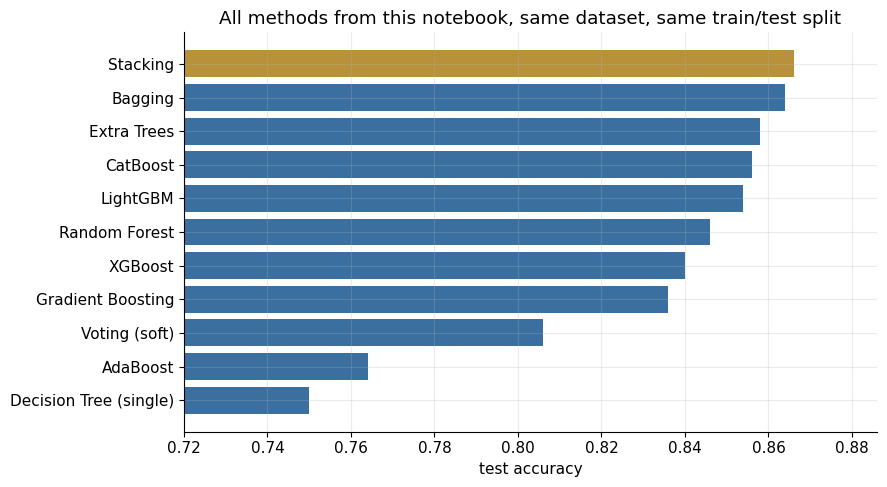

In [20]:
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier

models = {
    "Decision Tree (single)": DecisionTreeClassifier(max_depth=8, random_state=0),
    "Bagging":                BaggingClassifier(n_estimators=200, random_state=0, n_jobs=-1),
    "Random Forest":          RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1),
    "Extra Trees":            ExtraTreesClassifier(n_estimators=200, random_state=0, n_jobs=-1),
    "AdaBoost":               AdaBoostClassifier(n_estimators=200, random_state=0),
    "Gradient Boosting":      GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=0),
}
models["XGBoost"]   = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, verbosity=0)
models["LightGBM"]  = lgb.LGBMClassifier(n_estimators=200, num_leaves=31, learning_rate=0.1, verbosity=-1)
models["CatBoost"]  = CatBoostClassifier(iterations=200, depth=4, learning_rate=0.1, verbose=False)
models["Voting (soft)"] = VotingClassifier(estimators=base_models, voting="soft")
models["Stacking"]  = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(), cv=5)

rows = []
for name, model in models.items():
    t0 = time.time()
    model.fit(Xtr, ytr)
    fit_time = time.time() - t0
    acc = accuracy_score(yte, model.predict(Xte))
    rows.append((name, acc, fit_time))

rows.sort(key=lambda r: -r[1])
print(f"{'Model':<24}{'Test Accuracy':>15}{'Fit Time (s)':>15}")
print("-" * 54)
for name, acc, ft in rows:
    print(f"{name:<24}{acc:>15.3f}{ft:>15.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
names = [r[0] for r in rows]
accs = [r[1] for r in rows]
bar_colors = [COLORS["gold"] if a == max(accs) else COLORS["blue"] for a in accs]
ax.barh(names[::-1], accs[::-1], color=bar_colors[::-1])
ax.set_xlim(min(accs) - 0.03, max(accs) + 0.02)
ax.set_xlabel("test accuracy")
ax.set_title("All methods from this notebook, same dataset, same train/test split")
plt.tight_layout(); plt.show()

### 5.5 The Unifying Formula

Every method in this notebook is a special case of one expression:

$$\hat y(x) = \sum_{k=1}^K \beta_k\, h_k(x)$$

| Method | How $h_k$ is chosen | How $\beta_k$ is chosen |
|---|---|---|
| Bagging / RF / Extra Trees | Independently, on resampled data | Fixed, $\beta_k = 1/K$ |
| AdaBoost | Sequentially, reweighted data | Derived from each learner's error, $\alpha_t$ |
| Gradient Boosting / XGBoost / LightGBM / CatBoost | Sequentially, fit to the (pseudo-)gradient | Fixed learning rate $\nu$ |
| Voting | Independent, pre-trained models | Fixed / manually set |
| Stacking / Blending | Independent, pre-trained models | **Learned** by a meta-learner |

Once you see this common skeleton, "which ensemble should I use" becomes "how much control do I
want over $h_k$ vs. $\beta_k$, and how much compute can I spend getting there" — and every
technique in this notebook is really just a different, principled answer to that question.

### 5.6 Decision Guide

* **Safe, low-maintenance default** → Random Forest.
* **Maximum tabular accuracy, willing to tune** → XGBoost / LightGBM / CatBoost.
* **Training speed / huge datasets are the bottleneck** → LightGBM or Extra Trees.
* **Lots of high-cardinality categorical columns** → CatBoost.
* **Already have several good independent models** → Voting first (free), Stacking if you have
  the data/compute budget for a few more points of accuracy, Blending if you need a faster
  iteration loop and can spare a holdout slice.

---

## Closing Thought

Every method in this notebook, from bootstrap-sampled bagging to gradient-based boosting to
learned stacking, is chasing the exact same effect demonstrated in the very first cell: averaging
independent errors makes them cancel. The math in §1.1 ($\text{Var}(\bar y)=\sigma^2/n$) is the
seed; everything after it is an increasingly clever engineering answer to the same question —
*how do I keep my sub-models' mistakes from all being the same mistake?*

**Try next:** go back to any code cell above and change a hyperparameter — `max_features` in the
Random Forest correlation demo, `learning_rate` in the shrinkage demo, `num_leaves` in the
LightGBM demo — and re-run. Watching the plots move in response to a single number is the fastest
way to turn this math into intuition.